# 06 · Review of the one-time frozen test evaluation

The first code cell verifies the **committed pretest protocol** and archived final-result hashes. This notebook never opens the original test table or calls prediction. The explicit `make final-eval` command performed the single inference pass after the freeze commit; this repeatable notebook reviews its verified aggregate outputs.

All model/feature/calibration/capacity decisions remain those selected using training/validation. No final-test-driven choice is permitted.

In [1]:
import warnings

# Optional notebook progress widgets are not required for archived-result verification.
warnings.filterwarnings("ignore", message="IProgress not found.*", module=r"tqdm\..*")

from pathlib import Path
from readmit_iq.decision_support.freeze import verify_freeze
from readmit_iq.decision_support.final_evaluation import verify_published_results

root = Path.cwd()
lock, spec, freeze_commit = verify_freeze(root, require_models=False)
summary = verify_published_results(root)
print("Committed pretest freeze:", freeze_commit)
print("Original scoring pass:", summary["scoring"]["test_table_loads"], "test-table load")
print("Original prediction calls:", summary["scoring"]["prediction_calls"])
print("This review: zero test-table loads; zero prediction calls.")

Committed pretest freeze: ce2fcdb5c79256f088e82af45d97bb6d51a0360d
Original scoring pass: 1 test-table load
Original prediction calls: {'logistic__uncalibrated': 1, 'boosting__uncalibrated': 1}
This review: zero test-table loads; zero prediction calls.


In [2]:
import json
import os
import warnings
from pathlib import Path

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("NUMBA_CACHE_DIR", ".cache/numba")
# SHAP's legacy plotting helpers emit these unrelated import-time notices.
warnings.filterwarnings("ignore", category=PendingDeprecationWarning, module=r"shap\.plots.*")
warnings.filterwarnings("ignore", message="IProgress not found.*", module=r"tqdm.*")

from IPython.display import Image, Markdown, display
from readmit_iq.decision_support.plots import read_table, generate_figures

root = Path.cwd()
assert (root / "configs/phase5.yaml").exists()


## Frozen performance and patient-cluster uncertainty

The primary metric is average precision (AP). Bootstrap intervals resample whole patients, rerank at the fixed 10% capacity, and condition on the fitted models. They exclude model-selection/retraining and temporal/site uncertainty. Challenger results are descriptive; their test ranking cannot change the selected primary.

In [3]:
for partition in ["validation", "test"]:
    display(Markdown(f"**{partition.title()}**"))
    display(read_table(root, partition, "metrics")[["model", "average_precision", "roc_auc", "brier", "recall", "precision", "specificity", "tp", "fp", "fn", "lift"]])
display(read_table(root, "test", "metric_intervals"))
display(read_table(root, "test", "paired_comparisons"))

**Validation**

,model,average_precision,roc_auc,brier,recall,precision,specificity,tp,fp,fn,lift
0,logistic__uncalibrated,0.196781,0.654593,0.095065,0.214143,0.236203,0.914151,321,1038,1178,2.141428
1,boosting__uncalibrated,0.198721,0.661488,0.094604,0.224149,0.247241,0.915392,336,1023,1163,2.241494


**Test**

,model,average_precision,roc_auc,brier,recall,precision,specificity,tp,fp,fn,lift
0,logistic__uncalibrated,0.208368,0.651813,0.094101,0.235373,0.258493,0.916763,350,1004,1137,2.355297
1,boosting__uncalibrated,0.213109,0.659180,0.093664,0.231338,0.254062,0.916266,344,1010,1143,2.314920


,model,metric,ci_low,ci_high,valid_replicates
0,boosting__uncalibrated,average_precision,0.189957,0.240815,1000
1,boosting__uncalibrated,roc_auc,0.643135,0.676302,1000
2,boosting__uncalibrated,brier,0.089459,0.097840,1000
3,boosting__uncalibrated,recall,0.209693,0.255038,1000
4,boosting__uncalibrated,precision,0.223958,0.286136,1000
5,boosting__uncalibrated,lift,2.097380,2.551514,1000
6,logistic__uncalibrated,average_precision,0.187040,0.232850,1000
7,logistic__uncalibrated,roc_auc,0.635147,0.669287,1000
8,logistic__uncalibrated,brier,0.089817,0.098295,1000
9,logistic__uncalibrated,recall,0.212916,0.259085,1000


,metric,challenger_minus_primary,ci_low,ci_high
0,average_precision,0.004741,-0.002106,0.011006
1,roc_auc,0.007367,0.002461,0.012436
2,brier,-0.000437,-0.000805,-0.000069
3,recall,-0.004035,-0.015874,0.009030
4,precision,-0.004431,-0.017609,0.009707
5,lift,-0.040377,-0.158789,0.090340


## Operational results at the predeclared capacities

Top 10% remains the primary portfolio scenario. The realized risk cutoff is determined from unlabeled test ranks, not optimized against outcomes. The capacity grid and deciles describe the same frozen scores. Unique historical people are deduplicated within each selected set and cannot be added across capacities or scaled into concurrent workload.

In [4]:
display(read_table(root, "test", "capacity", True)[["capacity", "cutoff", "targeted_encounters", "targeted_patients", "tp", "fn", "recall", "precision", "lift"]])
display(read_table(root, "test", "risk_deciles", True).drop(columns=["model", "partition"]))
display(summary["scenario"])

,capacity,cutoff,targeted_encounters,targeted_patients,tp,fn,recall,precision,lift
0,0.05,0.219066,677,467,205,1282,0.137861,0.302806,2.759062
1,0.10,0.166509,1354,863,350,1137,0.235373,0.258493,2.355297
2,0.15,0.141997,2032,1304,452,1035,0.303968,0.222441,2.026801
3,0.20,0.130272,2709,1765,560,927,0.376597,0.206718,1.883542
4,0.25,0.121869,3387,2233,646,841,0.434432,0.190729,1.737855


,risk_group,encounters,patients,positives,observed_rate,mean_probability,cumulative_targeted,population_fraction,cumulative_captured,cumulative_recall,group_lift,cumulative_lift
0,1,1354,863,350,0.258493,0.253415,1354,0.099934,350,0.235373,2.355297,2.355297
1,2,1355,1188,210,0.154982,0.144746,2709,0.199941,560,0.376597,1.412135,1.883542
2,3,1355,1271,172,0.126937,0.121518,4064,0.299948,732,0.492266,1.156606,1.641170
3,4,1355,1274,154,0.113653,0.107126,5419,0.399956,886,0.595831,1.035566,1.489741
4,5,1355,1297,143,0.105535,0.095586,6774,0.499963,1029,0.691997,0.961597,1.384097
5,6,1355,1311,106,0.078229,0.087127,8129,0.599970,1135,0.763282,0.712792,1.272199
6,7,1355,1325,99,0.073063,0.082011,9484,0.699978,1234,0.829859,0.665721,1.185550
7,8,1355,1329,102,0.075277,0.076534,10839,0.799985,1336,0.898453,0.685894,1.123087
8,9,1355,1331,69,0.050923,0.070368,12194,0.899993,1405,0.944855,0.463987,1.049848
9,10,1355,1328,82,0.060517,0.058227,13549,1.000000,1487,1.000000,0.551405,1.000000


{'scenario': 'Illustrative operational scenario; capacity is a portfolio assumption',
 'eligible_discharges': 10000,
 'expected_observed_readmissions': 1097.4979703299136,
 'outreach_encounters': 999.3357443353754,
 'model_surfaced_readmissions': 258.32164735404825,
 'random_surfaced_readmissions': 109.6768951086208,
 'additional_surfaced_readmissions': 148.64475224542747,
 'number_needed_to_contact': 3.8685714285714288,
 'prevention_effect_estimated': False,
 'unique_people_scaled': False}

## Prespecified errors and responsible-ML diagnostics

Apply exactly the validation subgroup definitions, size rules and probability-bias criterion. These diagnostics characterize failures; they do not reopen model or threshold selection. Earlier full-cohort EDA and historical/fragmented capture limit the strength of this held-out evaluation.

In [5]:
display(read_table(root, "test", "error_profiles", True).drop(columns=["model", "partition"]))
groups = read_table(root, "test", "subgroups", True)
display(groups.loc[groups.group.isin(["prior_inpatient", "gender", "race"]), ["group", "level", "encounters", "positives", "suppressed", "prevalence", "recall", "recall_ci_low", "recall_ci_high", "precision", "probability_bias", "material_probability_bias"]])
display(groups.loc[groups.material_probability_bias.eq(True), ["group", "level", "probability_bias", "probability_bias_ci_low", "probability_bias_ci_high"]])

,cohort,encounters,patients,mean_probability,median_stay,no_prior_inpatient_fraction,no_prior_emergency_fraction
0,all_readmissions,1487,1189,0.144512,4.0,0.503026,0.829859
1,false_negative,1137,1014,0.102368,4.0,0.607740,0.867194
2,false_positive,1004,732,0.243653,5.0,0.148406,0.750996
3,low_utilization_false_negative,691,688,0.090263,4.0,1.000000,0.892909
4,low_utilization_true_positive,57,57,0.238773,5.0,1.000000,0.964912


,group,level,encounters,positives,suppressed,prevalence,recall,recall_ci_low,recall_ci_high,precision,probability_bias,material_probability_bias
0,prior_inpatient,Any,4468,739,False,0.165398,0.396482,0.350681,0.442283,0.255226,-0.012087,False
1,prior_inpatient,None,9081,748,False,0.082370,0.076203,0.057207,0.095199,0.276699,0.005806,False
16,gender,Female,7277,797,False,0.109523,0.235885,0.197804,0.273965,0.258953,-0.000443,False
17,gender,Male,6272,690,False,0.110013,0.234783,0.189863,0.279702,0.257962,0.000309,False
18,race,AfricanAmerican,2576,294,False,0.114130,0.234694,0.153233,0.316155,0.232323,-0.001657,False
19,race,Asian,66,1,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,race,Caucasian,10155,1142,False,0.112457,0.239054,0.207916,0.270192,0.269763,-0.002406,False
21,race,Hispanic,236,14,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,race,Other,211,20,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,race,Unknown,305,16,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,group,level,probability_bias,probability_bias_ci_low,probability_bias_ci_high


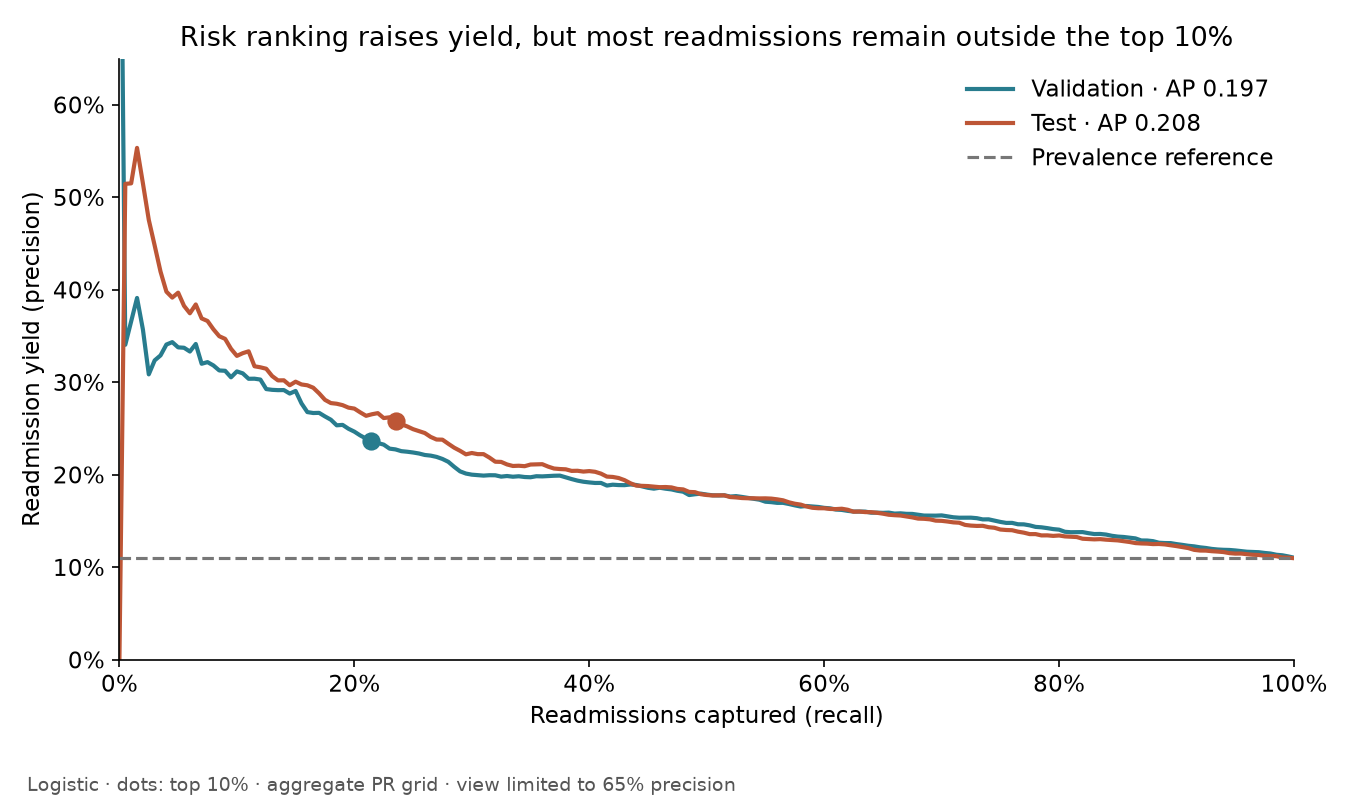

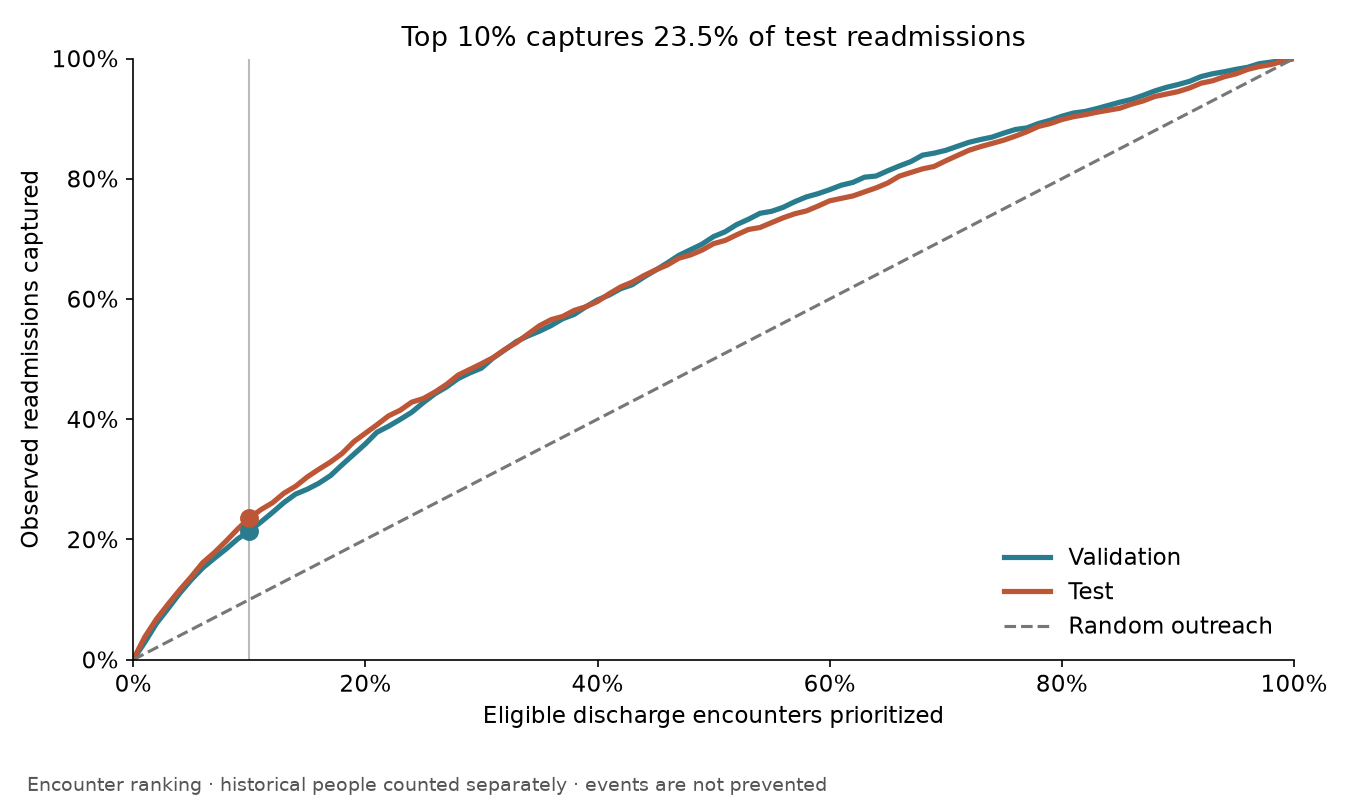

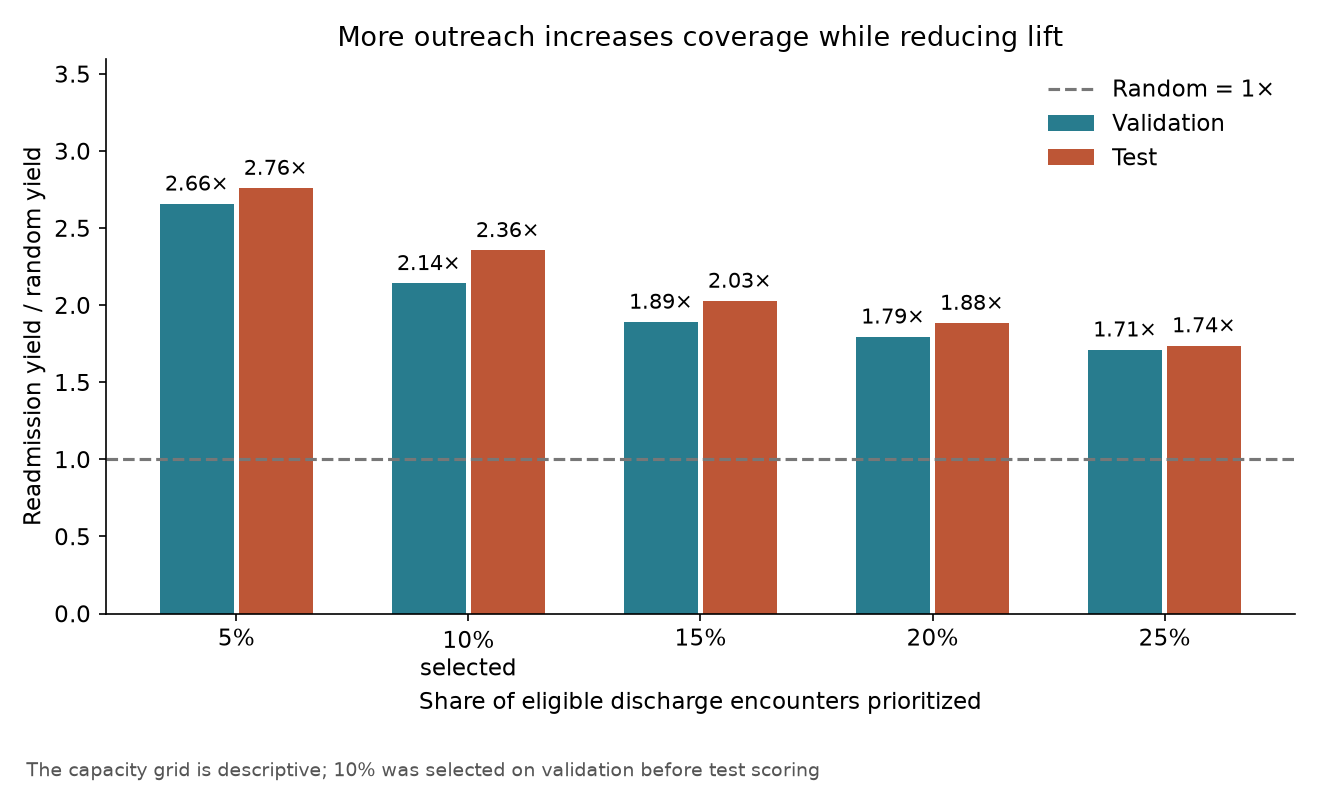

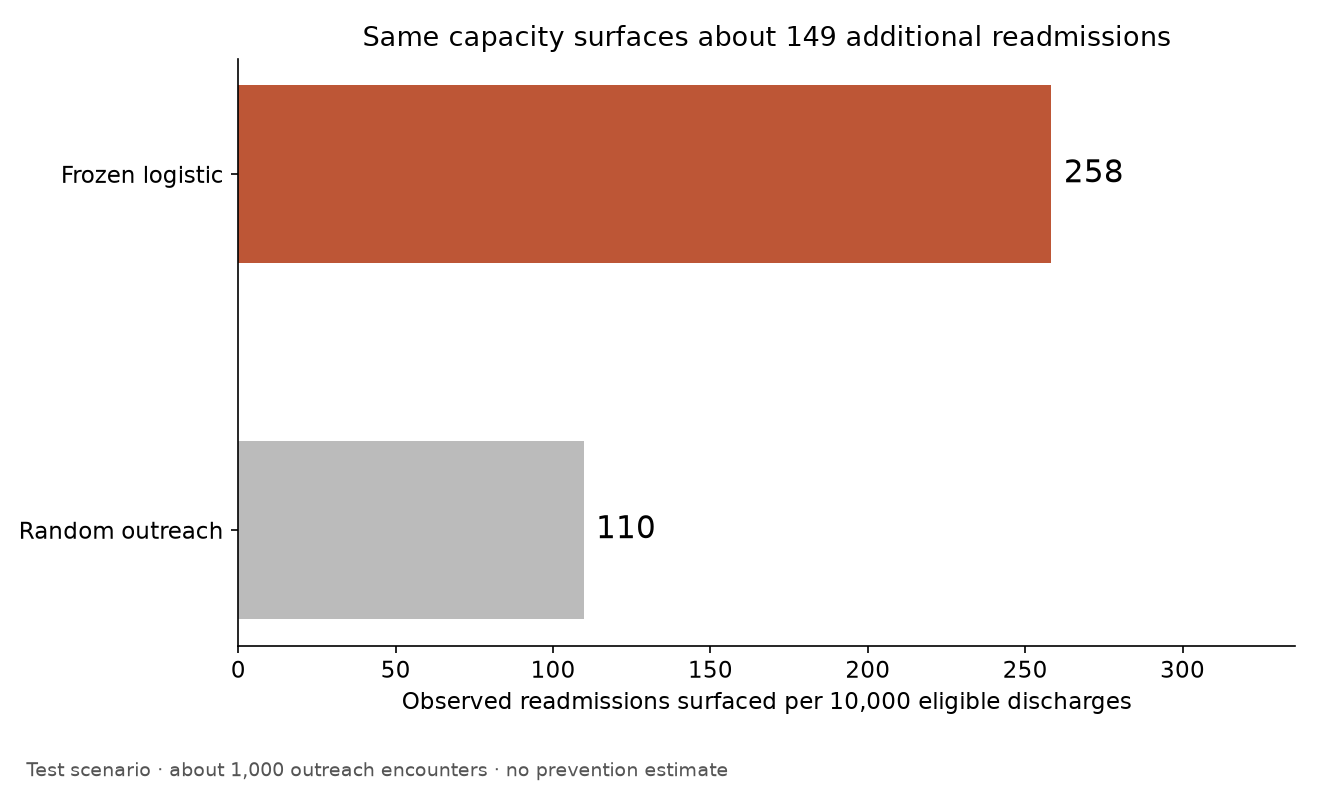

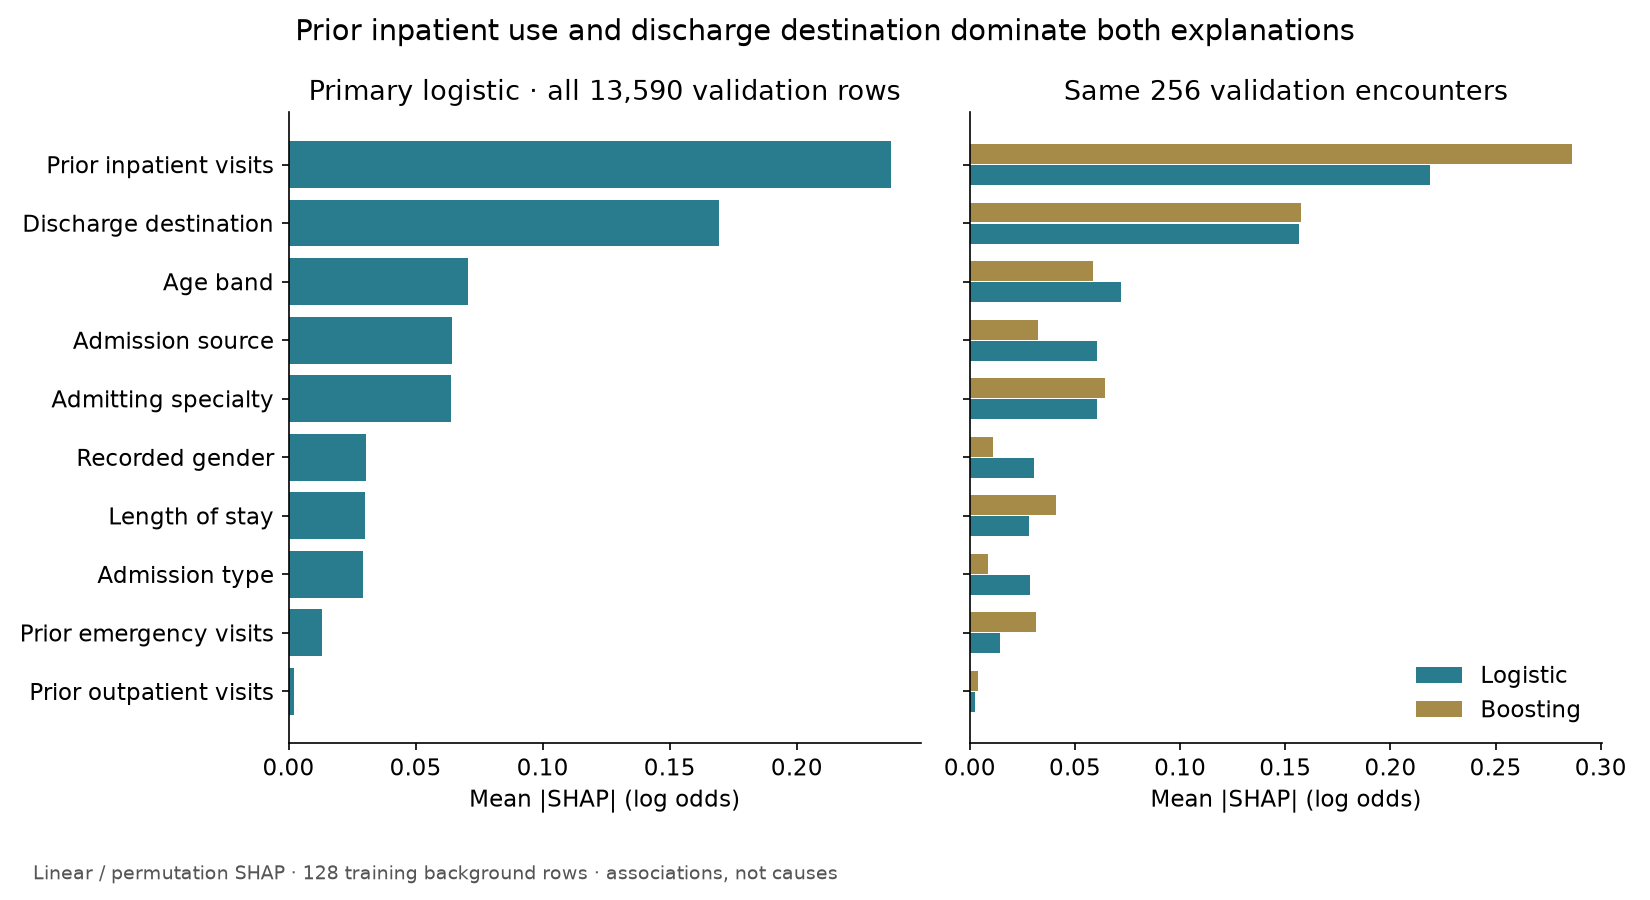

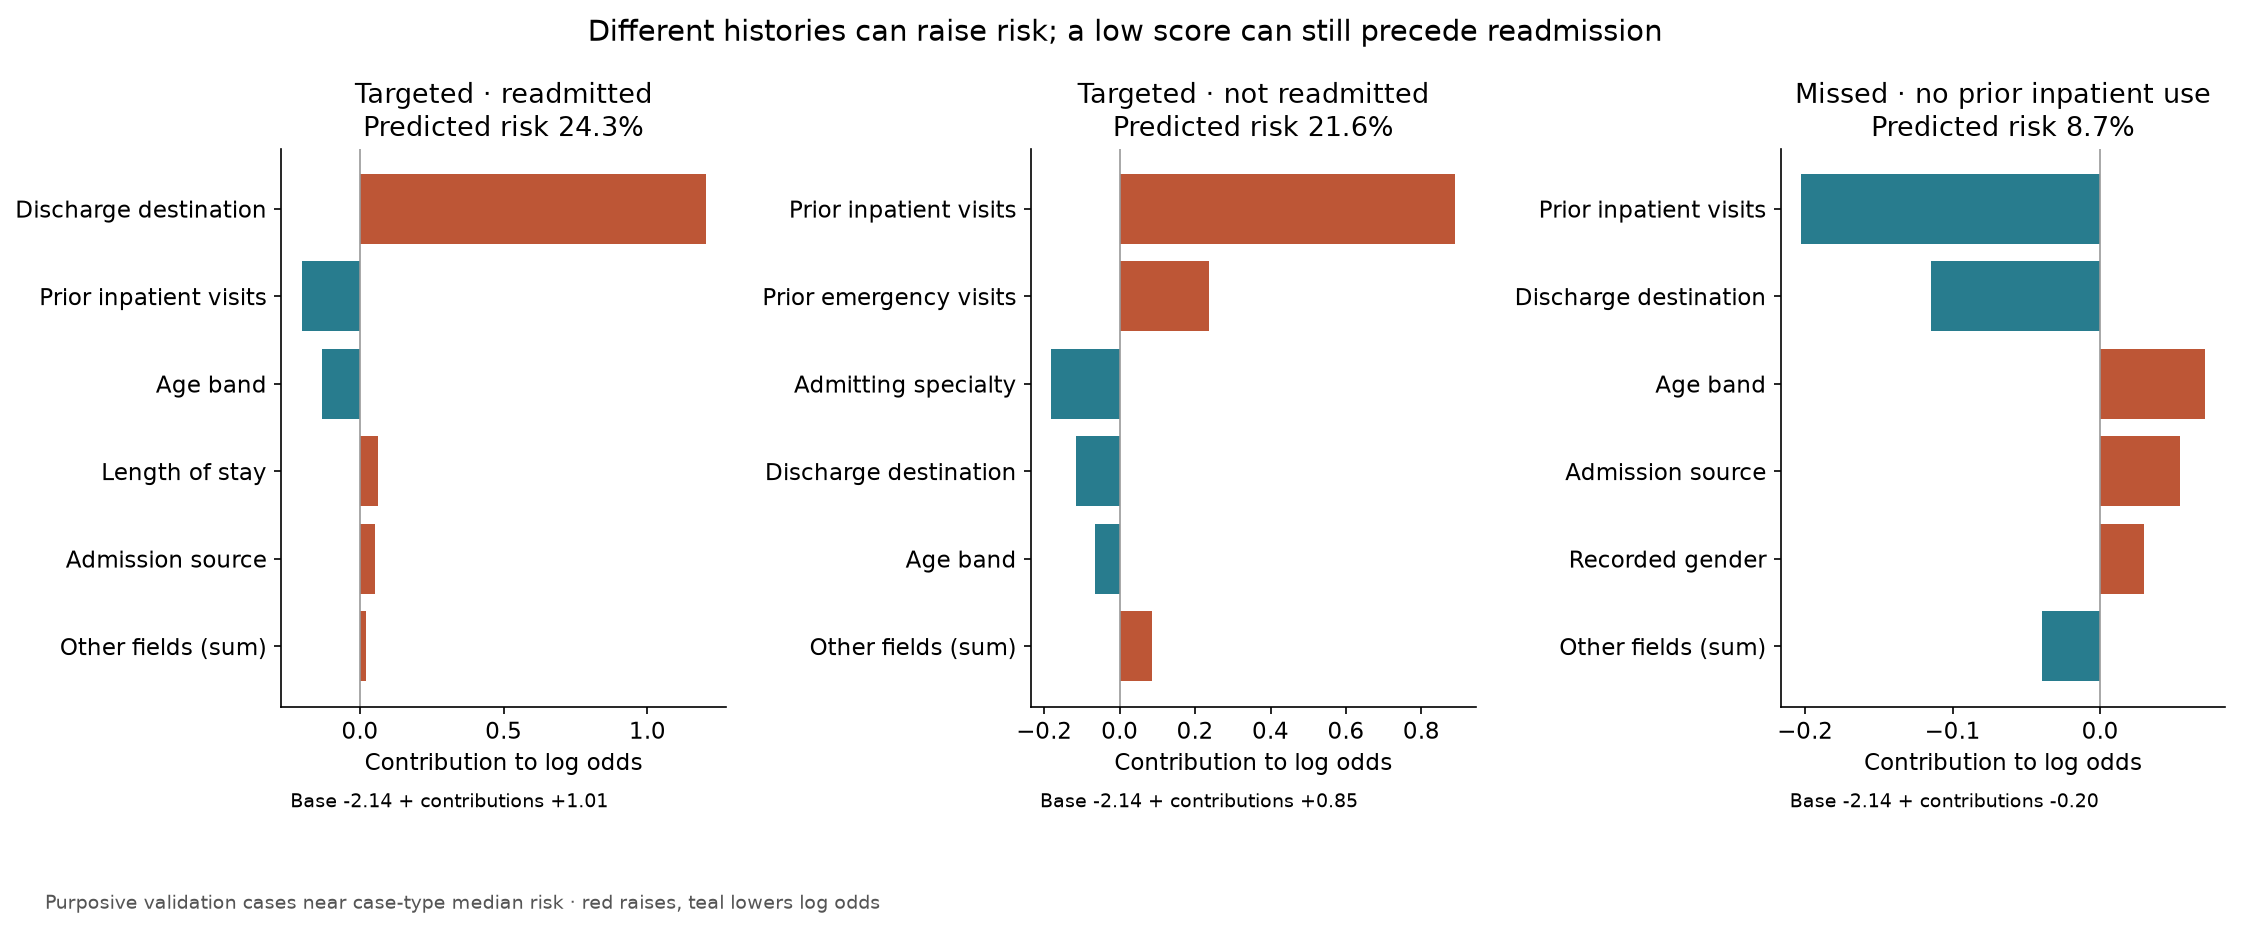

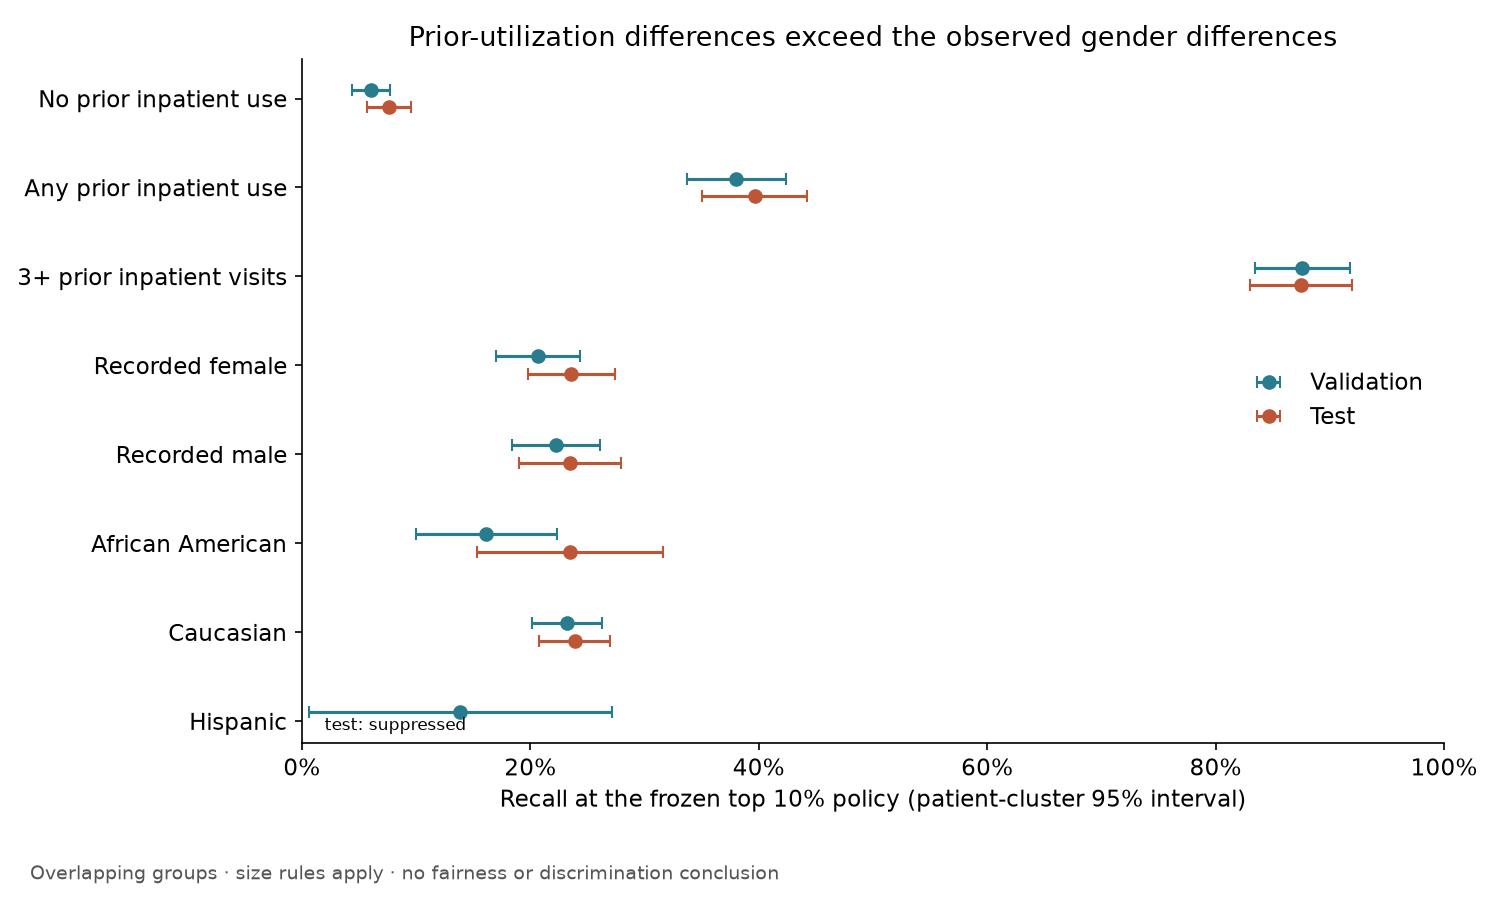

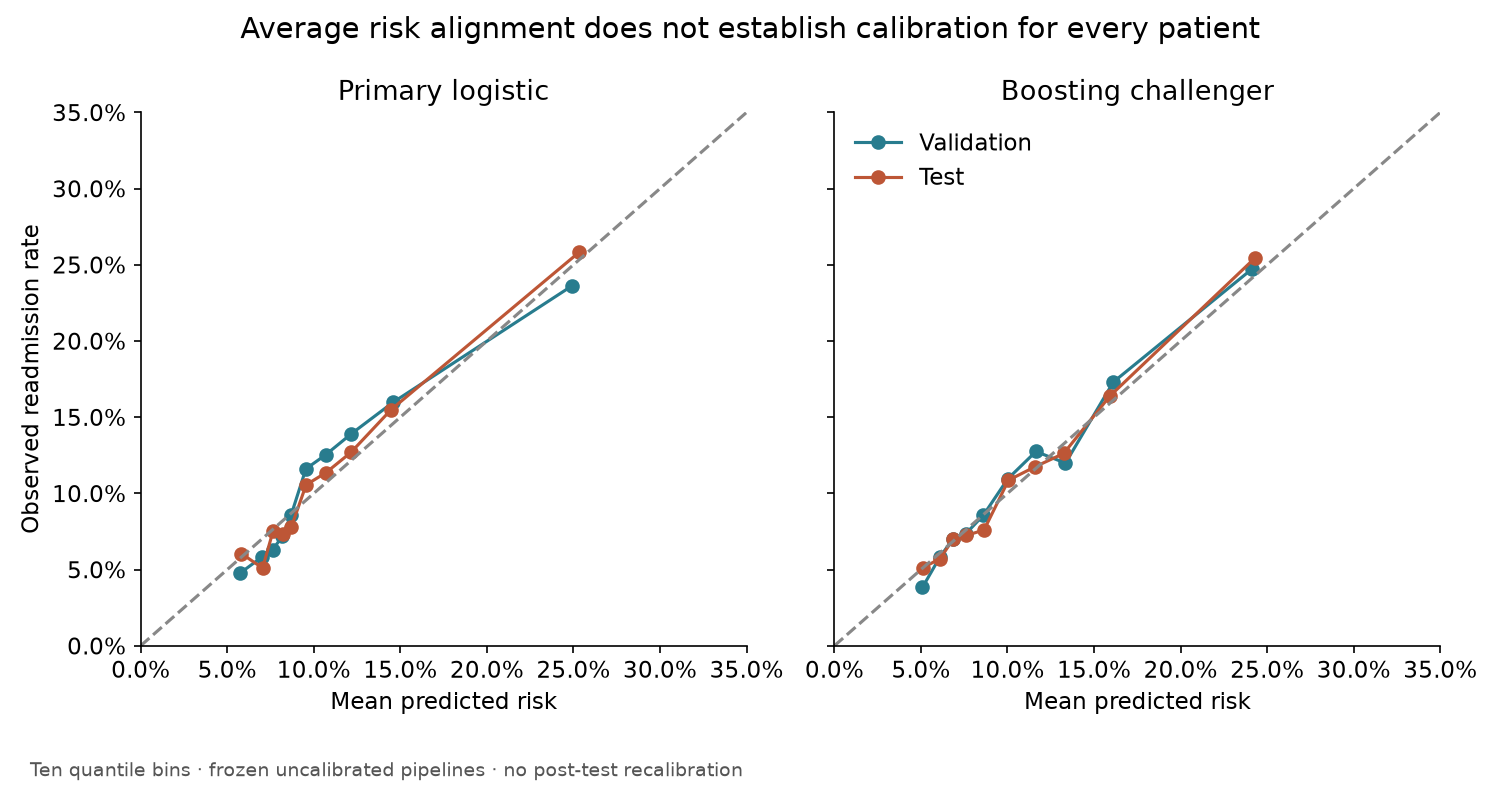

In [6]:
# Read only the eight reviewed committed figures. Validation explanations remain validation-only.
figures = sorted((root / "reports/figures/phase5").glob("*.png"))
assert len(figures) == 8
for path in figures:
    display(Image(filename=str(path)))

In [7]:
metadata = json.loads((root / "reports/modeling/final_model_metadata.json").read_text())
assert metadata["model_refitted_after_test"] is False
assert summary["decision_changes_after_test"] is False
assert metadata["targeting"] == lock["policy"]["targeting"]
display({key: metadata[key] for key in ["version", "primary", "pipeline_sha256", "training_commit", "freeze_commit", "features", "clinical_deployment_validated"]})

{'version': '1.0.0-frozen-portfolio',
 'primary': 'logistic__uncalibrated',
 'pipeline_sha256': 'ff82996f1f49008dec373655d53cf95a2ce5d940cb7dbc2bd1e25ea6fe447fa8',
 'training_commit': 'a48c68b10e0339e95c934ea4ab6b1ee7ff00a904',
 'freeze_commit': 'ce2fcdb5c79256f088e82af45d97bb6d51a0360d',
 'features': ['time_in_hospital',
  'number_inpatient',
  'number_emergency',
  'number_outpatient',
  'age',
  'gender',
  'admission_type_id',
  'admission_source_id',
  'discharge_disposition_id',
  'medical_specialty'],
 'clinical_deployment_validated': False}

## Scope and interpretation

Read the [final result narrative](../reports/modeling/final_test_report.md) and [responsible ML diagnostics](../reports/responsible_ml.md). A surfaced readmission is not a prevented readmission. Contemporary external/temporal and prospective clinical/workflow validation are still needed. No service, dashboard, Docker image or deployment is built in this phase.